# Search for optimal partition with minimal description length based on Map equation
The original paper proposes a greedy search followed by simulated annealing, but in the 2009 publication "The map equation" by M. Rosvall1, D. Axelsson, and C.T. Bergstrom, a method supposedly as fast but more accurate than the method from the OG paper was introduced. It's described as follows:

## 5 Fast stochastic and recursive search algorithm
Any greedy (fast but inaccurate) or Monte Carlo-based (accurate but slow) approach can be 
used to minimize the map equation. To provide a good balance between the two extremes, 
we have developed a fast stochastic and recursive search algorithm, implemented it in C++, 
and made it available online both for directed and undirected weighted networks [25]. As a 
reference, the new algorithm is as fast as the previous high-speed algorithms (the greedy search 
presented in the supporting appendix of Ref. [14]), which were based on the method introduced 
in Ref. [26] and reﬁned in Ref. [27]. At the same time, it is also more accurate than our previous 
high-accuracy algorithm (a simulated annealing approach) presented in the same supporting 
appendix.

The core of the algorithm follows closely the method presented in Ref. [28]: neighboring 
nodes are joined into modules, which subsequently are joined into supermodules and so on. 
First, each node is assigned to its own module. Then, in random sequential order, each node is 
moved to the neighboring module that results in the largest decrease of the map equation. If 
no move results in a decrease of the map equation, the node stays in its original module. This 
procedure is repeated, each time in a new random sequential order, until no move generates a 
decrease of the map equation. Now the network is rebuilt, with the modules of the last level 
forming the nodes at this level. And exactly as at the previous level, the nodes are joined into 
modules. This hierarchical rebuilding of the network is repeated until the map equation cannot 
be reduced further. Except for the random sequence order, this is the algorithm described in 
Ref. [28].

With this algorithm, a fairly good clustering of the network can be found in a very short 
time. Let us call this the core algorithm and see how it can be improved. The nodes assigned to 
the same module are forced to move jointly when the network is rebuilt. As a result, what was
an optimal move early in the algorithm might have the opposite eﬀect later in the algorithm. 
Because two or more modules that merge together and form one single module when the network 
is rebuilt can never be separated again in this algorithm, the accuracy can be improved by 
breaking the modules of the ﬁnal state of the core algorithm in either of the two following ways:

*Submodule movements*. First, each cluster is treated as a network on its own and the main 
algorithm is applied to this network. This procedure generates one or more submodules 
for each module. Then all submodules are moved back to their respective modules of the 
previous step. At this stage, with the same partition as in the previous step but with 
each submodule being freely movable between the modules, the main algorithm is re-applied.

*Single-node movements*. First, each node is re-assigned to be the sole member of its own 
module, in order to allow for single-node movements. Then all nodes are moved back to 
their respective modules of the previous step. At this stage, with the same partition as in 
the previous step but with each single node being freely movable between the modules, the 
main algorithm is re-applied.

In practice, we repeat the two extensions to the core algorithm in sequence and as long as the 
clustering is improved. Moreover, we apply the submodule movements recursively. That is, to 
ﬁnd the submodules to be moved, the algorithm ﬁrst splits the submodules into subsubmodules, 
subsubsubmodules, and so on until no further splits are possible. Finally, because the algorithm 
is stochastic and fast, we can restart the algorithm from scratch every time the clustering cannot 
be improved further and the algorithm stops. The implementation is straightforward and, by 
repeating the search more than once, 100 times or more if possible, the ﬁnal partition is less 
likely to correspond to a local minimum. For each iteration, we record the clustering if the 
description length is shorter than the previously shortest description length. In practice, for 
networks with on the order of 10,000 nodes and 1,000,000 directed and weighted links, each 
iteration takes about 5 seconds on a modern PC

Phase 1:
- initially assign each node to a different communitiy ($N$ nodes -> $N$ communities)
- for each node i, consider neighbours j, check if/how much removing i from its community and putting it into j's community improves (decreases) description length
- choose neighbour merge with best improvement. If no improvement possible, i stays in its community.
- repeat sequentially for all nodes until no further improvement can be made -> Phase 1 done!

Phase 2:
- build a new network whose nodes are the communities found in phase 1
- weights of links between new nodes correspond to sum of weight of links between old nodes in the corresponding 2 communities; links between nodes of the same community lead to self-loops for this community in the new network -> Phase 2 done! Can reapply Phase 1 to new network.

Iterate Phase 1 + Phase 2 until no further improvements are obtained.
Refinement possible with submodule/single-module movements -> can be performed in sequence until no more improvements.

The following functions are (presumably) needed to tackle this:
- `update_node_move_description_length()`: Computes the change in description length for a given community partition in the event that a single node is moved from its community to another community. (for phase 1) -> DONE, tested in `Test_infomap.ipynb`.
- `node_movement_optimization()`: Basically runs the Phase 1. Sequentially goes through nodes in random order, finds the optimal move using `update_node_move_description_length()`, and repeats until no improving moves can be made. -> DONE
- `compress_network()`: Implements Phase 2. Takes the community assignment and transforms it into a new network with nodes corresponding to the communities, and aggregates the weights of the within- and between-community links into self-loops and links between nodes on the new network. -> DONE

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings
import random
import sys
sys.path.append("..") # go to parent folder
import src.infomap_funcs as inf # import infomap_funcs from src folder

Let's try to do the node movement optimization:
(Some mild confusion: One of the references makes it sound as though we keep sequentially going through all nodes again until no more improvements are possible, the other one suggests that we keep track of candidate nodes and, if at any point, a node has no further moves for improvement it is removed from the candidate pool, which unlike the first option sounds like it may neglect combinations where after a change in constellation a node that previously didn't have an improving move might now have one with the new, changed modules. We'll see? I'll start implementing option one, and then we can see if the candidate pool makes sense or not.)

In [2]:
g_test = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=True)
communities, L, p_mod, exit_data = inf.node_movement_optimization(g_test, returnTerms=True, verbose=True)

Starting from description length: 8.546360489589002
Current best description length: 6.49029651375826
Number of nodes that have been moved this iteration: 69
Continuing optimization.
Current best description length: 6.220616912822287
Number of nodes that have been moved this iteration: 17
Continuing optimization.
Current best description length: 6.182838464235799
Number of nodes that have been moved this iteration: 6
Continuing optimization.
Current best description length: 6.147636675823291
Number of nodes that have been moved this iteration: 2
Continuing optimization.
Current best description length: 6.14735434857759
Number of nodes that have been moved this iteration: 2
Continuing optimization.
Current best description length: 6.123224167396384
Number of nodes that have been moved this iteration: 2
Continuing optimization.
Current best description length: 6.118490046362071
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length

In [3]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", inf.compute_description_length(g_test, communities))

optimization function output L:  5.889896550689507
recomputed description length:  5.889896550689502


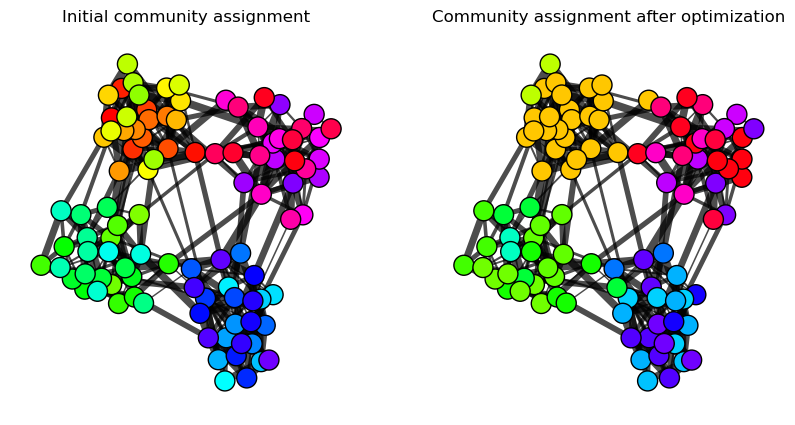

In [4]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=np.arange(g_test.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

In [5]:
g_test_directed = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities_directed, L, p_mod, exit_data = inf.node_movement_optimization(g_test_directed, returnTerms=True, verbose=True)

Starting from description length: 8.505433022994854
Current best description length: 6.791906531252538
Number of nodes that have been moved this iteration: 76
Continuing optimization.
Current best description length: 6.575918597253177
Number of nodes that have been moved this iteration: 18
Continuing optimization.
Current best description length: 6.505140243744333
Number of nodes that have been moved this iteration: 10
Continuing optimization.
Current best description length: 6.488543699266048
Number of nodes that have been moved this iteration: 2
Continuing optimization.
Current best description length: 6.488543699266048
Number of nodes that have been moved this iteration: 0
Optimization finished!
Final number of communities: 20
Final description length: 6.488543699266048


In [6]:
# check the new description length, should be same as before:
print("optimization function output L: ", L)
print("recomputed description length: ", inf.compute_description_length(g_test_directed, communities_directed))

optimization function output L:  6.488543699266048
recomputed description length:  6.4885436992660495


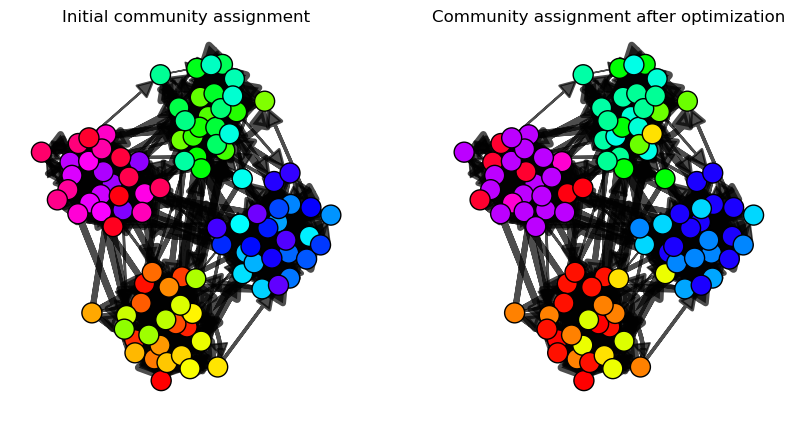

In [7]:
layout_directed = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=np.arange(g_test_directed.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

### Network compression (search algorithm phase II)
Let's test the network compression function!

Testing with undirected test network from above:

In [8]:
g_test_compressed, unique_communities = inf.compress_network(g_test, communities, verbose=True)

Input graph has 24 unique communities, 100 nodes and 347 edges.
Creating compressed graph with 24 nodes, 143 aggregated edges.


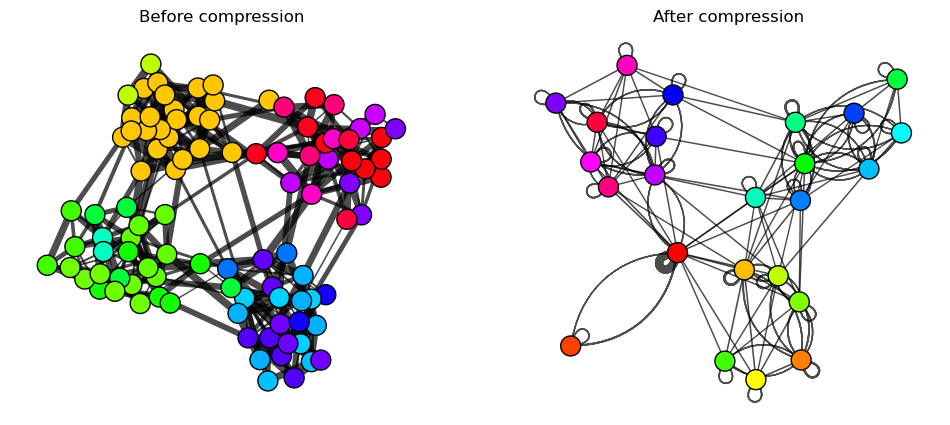

In [9]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[0])
ig.plot(g_test_compressed, **inf.visual_community_colors(g_test_compressed, communities=range(g_test_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [10]:
# check the new description length:
print("Codelength before compression: ", inf.compute_description_length(g_test, communities))
print("Codelength after compression: ", inf.compute_description_length(g_test_compressed, range(g_test_compressed.vcount())))

Codelength before compression:  5.889896550689502
Codelength after compression:  3.3599469442065057


In [11]:
# let's check if the difference is as expected:
L,  p, p_mod, exits = inf.compute_description_length(g_test, communities, returnTerms=True)
L_comp,  p_c, p_mod_c, exits_c = inf.compute_description_length(g_test_compressed, range(g_test_compressed.vcount()), returnTerms=True)
print(f"Before compression:\nL = {L} \nH(p) = {np.sum(inf.safe_xlogx(p))} \nH(p_mod) = {np.sum(inf.safe_xlogx(p_mod))}\n")
print(f"After compression:\nL = {L_comp} \nH(p) = {np.sum(inf.safe_xlogx(p_c))} \nH(p_mod) = {np.sum(inf.safe_xlogx(p_mod_c))}")

print("Codelength difference in theory: ", np.sum(inf.safe_xlogx(p_mod)) - np.sum(inf.safe_xlogx(p)))
print("Actual codelength difference: ", L - L_comp)

Before compression:
L = 5.889896550689502 
H(p) = -6.546360489589 
H(p_mod) = -4.016410883106003

After compression:
L = 3.3599469442065057 
H(p) = -4.016410883106003 
H(p_mod) = -4.016410883106003
Codelength difference in theory:  2.5299496064829974
Actual codelength difference:  2.5299496064829965


Testing with the directed test network from above:

In [12]:
g_test_directed_compressed, unique_communities_directed = inf.compress_network(g_test_directed, communities_directed, verbose=True)

Input graph has 20 unique communities, 100 nodes and 679 edges.
Creating compressed graph with 20 nodes, 169 aggregated edges.


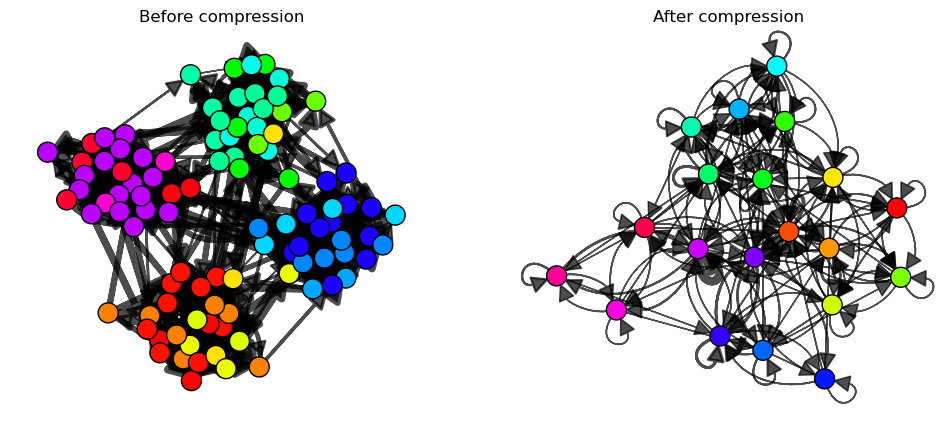

In [13]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[0])
ig.plot(g_test_directed_compressed, **inf.visual_community_colors(g_test_directed_compressed, communities=range(g_test_directed_compressed.vcount())), target=ax[1])
ax[0].set_title("Before compression")
ax[1].set_title("After compression")
plt.show()

In [14]:
# check the new description length:
# we can't evaluate the difference as neatly as in the undirected case 
# bc with directed networks the changes are a lot more complex
print("Codelength before compression: ", inf.compute_description_length(g_test_directed, communities_directed))
print("Codelength after compression: ", inf.compute_description_length(g_test_directed_compressed, range(g_test_directed_compressed.vcount())))

Codelength before compression:  6.4885436992660495
Codelength after compression:  4.467909411576826


### Refinements: Recursive submodule movements

Now, we implement the submodule movements as described above, and employ them recursively:

In [ ]:
# first, this is the core search algorithm without any refinements:
def core_search_algorithm(g:ig.Graph, verbose=False):

    N = g.vcount() # number of nodes in graph
    flat_comms = np.arange(N, dtype=int) # we'll use this to track how each node in the og graph
    # maps to the supernodes of the current compressed graph

    g_current = g 
    level = 0 # tracking the compression depth

    # start with a loop that repeats as long as we still have improvements:
    improved = True
    while improved:
        n_current = g_current.vcount()
        if verbose:
            print(f"\n--- Level {level} ------------------------------")
            print(f"    Current Graph: {n_current} nodes, {g_current.ecount()} edges")
    
        # --- Phase 1: optimization via single-node moves ---
        comms_level = inf.node_movement_optimization(g_current, verbose=verbose)
        comms_unique = np.unique(comms_level) # get sorted list of unique communities
        n_communities = len(comms_unique) # number of unique communities

        if verbose:
            print(f"    Phase 1 found {n_communities} communities")

        # if no improvement has been made in node movement optimization, exit loop
        if n_communities == n_current:  # if we still have 1 community per node after node optimization
            if verbose:
                print(f"    Moving (super)nodes didn't improve codelength, stopping optimization.")
            break

        # --- Update node mapping ---
        # get for each node in the current level graph the corresponding community
        # indices after optimization (corresponding to supernode indices of the compressed graph
        # that will be created in the next step
        node_to_super = np.searchsorted(comms_unique, comms_level)  # shape (n_current,)
        # get mapping back to og nodes
        flat_comms    = node_to_super[flat_comms]         
        
        # --- Phase 2: Network compression ---
        g_current, _ = inf.compress_network(g_current, comms_level, verbose=verbose)
        if verbose: 
            print(f"    Compressed network has description length L = {inf.compute_description_length(g_current, range(n_communities))}")
        level += 1
        
    # Normalise: make community labels contiguous and 0-indexed. 
    # (bc rn the labels could have gaps) 
    # works neatly with the inverse labels from np.unique
    _, flat_comms = np.unique(flat_comms, return_inverse=True)

    if verbose:
        L_final = inf.compute_description_length(g, flat_comms.tolist())
        print(f"\nFinal: {len(np.unique(flat_comms))} communities, "
              f"L = {L_final:.6f} bits")

    return flat_comms.tolist()
        
# the recursive submodule search function
def search_submodules_with_recursion(g, verbose=False):
    N = g.vcount()
    # recursive splitting endds when we have just one node:
    if N <= 1:
        if verbose:
            print(f"Base case reached with singleton node (N={N}). Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    comms = inf.node_movement_optimization(g, verbose=verbose)
    unique_comms = np.unique(comms)
    n_comms = len(unique_comms)
    if n_comms == 1:
        if verbose: 
            print(f"No improving split for given {N} nodes found. Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    # now, if there were still improvements to be made, split into submodules & recurse
    comms_idx = np.searchsorted(unique_comms, comms)   # re-index to 0, 1, 2, ...
    result = np.empty(g.vcount(), dtype=int) # for storing result community assignment
    next_label = 0 # for tracking proper labelling, as done in the core function
    for i in range(n_comms):
        # node indices belonging to current module (list of 1-D arrays)
        comm_nodes = np.where(comms_idx == i)[0]

        # again, handle single-node case -> increase label
        if len(comm_nodes) == 1:                      # singleton - can't go deeper
            result[comm_nodes] = next_label
            next_label += 1
            continue

        # otherwise: build subgraph and recurse
        subgraph = g.induced_subgraph(comm_nodes)
        sub_comms = search_submodules_with_recursion(subgraph, verbose=verbose)
        # then shift community_labels by offset to make them globally unique.
        for s in np.unique(sub_comms):
            result[comm_nodes[sub_comms == s]] = next_label
            next_label += 1

    return result

# the main submodule optimization fucntion, which can be called with recursion using the aboe function
# or without, just performing a single round of submodule splitting and moving
def submodule_movement_optimization(g: ig.Graph, communities: list[int]=None, recursion=False, verbose=False) -> np.ndarray:
    """Refine a community partition via submodule movements:
    1. Take subgraphs corresponding to each module and run node-movement optimization to get 
        submodules
    2. Compress full network such that supernodes correspond to submodules
    3. Run node-movement optimization again, but startunf from the parent-module assignments

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        communities (list[int] | np.ndarray): Community label for each node. Labels need
            not be 0-indexed or contiguous (gaps from prior merge steps are handled).
        verbose (bool, optional): Print progress information. Defaults to False.

    Returns:
        np.ndarray: Refined community assignment for every node of g.
    """
    if communities is None:
        if verbose:
            print("No initial partition provided, running core search algorithm first.")
        communities = core_search_algorithm(g, verbose=verbose)

    communities = np.array(communities, dtype=int)

    # Normalise community labels to contiguous 0-indexed integers.
    unique_comms = np.unique(communities)          # sorted unique labels
    n_mods       = len(unique_comms)
    comm_idx     = np.searchsorted(unique_comms, communities)   # 0-indexed community per node

    # node indices belonging to each module (list of 1-D arrays)
    comm_nodes = [np.where(comm_idx == i)[0] for i in range(n_mods)]

    if verbose:
        print(f"Submodule refinement: Starting with {n_mods} modules, {g.vcount()} nodes total.")
        for i, (comm, nodes) in enumerate(zip(unique_comms, comm_nodes)):
            print(f"  Module {comm} (idx {i}): {len(nodes)} nodes.")

    # Take each module and extract the corresponding subgraph, 
    # run the main node-movement optimisation and map the resulting local labels
    # to globally unique integers, simultaneously recording each submodule's
    # parent module index.
    global_submodule = np.empty(g.vcount(), dtype=int)  # global submodule label per node
    submodule_to_parent: list[int] = []  # parent module idx per submodule

    offset = 0 # offset to help with contiguous submodule labelling 
    for mod_idx, (nodes, subgraph) in enumerate(
        zip(comm_nodes, [g.induced_subgraph(nodes) for nodes in comm_nodes])): # get subgraphs corresponding to each community
        
        if recursion:
            # start recursive process
            local_comms = search_submodules_with_recursion(subgraph, verbose=verbose)
        else:
            # no recursion,just perform node movement optimization step
            local_comms = np.array(inf.node_movement_optimization(subgraph, verbose=verbose), dtype=int)

        # Normalise local labels to contiguous 0-indexed integers,
        # then shift by offset to make them globally unique.
        local_unique  = np.unique(local_comms) # unique local submodule labels
        local_idx     = np.searchsorted(local_unique, local_comms)  # 0-indexed within module
        n_submodules  = len(local_unique) # number of submodules for the given subgraph

        global_submodule[nodes] = local_idx + offset # global submodule labels

        # Each local submodule belongs to the current parent module.
        submodule_to_parent.extend([mod_idx] * n_submodules) # update parent map
        offset += n_submodules # update offset

    submodule_to_parent = np.array(submodule_to_parent, dtype=int)
    n_total_submodules  = offset # total number of submodules

    if verbose:
        print(f"Created {n_total_submodules} submodules across {n_mods} modules.")

    # Network compression: each supernode corresponds to one submodule.
    # also returns unique submodule labels to allow reconstruction of node assignments
    g_compressed, unique_submodule_labels = inf.compress_network(g, global_submodule, verbose=verbose)


    # unique_submodule_labels[i] is the global submodule label of compressed node i,
    # so indexing submodule_to_parent with it gives the parent module index for each compressed node.
    initial_compressed_comms = submodule_to_parent[unique_submodule_labels]

    if verbose:
        print(f"  Compressed nodes: {g_compressed.vcount()}, "
              f"unique initial communities: {len(np.unique(initial_compressed_comms))}")

    # Performing node-movement optimization on compressed network, with an initial
    # community partition corresponding to the result of the core search algorithm
    # so each compressed node (submodule) is initially assigned to its parent module.
    final_compressed_comms = np.array(
        inf.node_movement_optimization(g_compressed,
                                       initial_communities=initial_compressed_comms,
                                       verbose=verbose,
                                       ),
        dtype=int,
    )

    # map the refined partition back to og nodes
    compressed_node_idx = np.searchsorted(unique_submodule_labels, global_submodule)
    final_communities   = final_compressed_comms[compressed_node_idx]

    if verbose:
        n_final = len(np.unique(final_communities))
        print(f"Submodule refinement complete: {n_mods} -> {n_final} communities.")

    return final_communities

Time to test them, first the undirected case:

In [ ]:
initial_partition = core_search_algorithm(g_test, verbose=True)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test, initial_partition, recursion=True,verbose=True)

print("Before:", inf.compute_description_length(g_test, initial_partition))
print("After: ", inf.compute_description_length(g_test, refined_partition))

Then directed:

In [ ]:
initial_partition = core_search_algorithm(g_test_directed, verbose=True)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test_directed, initial_partition, recursion=True,verbose=True)

print("Before:", inf.compute_description_length(g_test_directed, initial_partition))
print("After: ", inf.compute_description_length(g_test_directed, refined_partition))

### Full optimization workflow

In [ ]:
def search_community_partition(g:ig.Graph, max_iter=100, verbose=False):

    N = g.vcount() # number of nodes in graph
    if verbose:
        print(f"\n---  Starting community partition search------------------------------")
        print(f"    Current Graph: {N} nodes, {g.ecount()} edges")
        print(f"    Starting from description length L = {inf.compute_description_length(g, range(N))} bits (with trivial parititon)")

    comms_initial = core_search_algorithm(g, verbose=verbose) # runs core optimization

    if verbose:
        L_initial = inf.compute_description_length(g, comms_initial)
        print(f"Initial partition found by core search algorithm has description length L = {L_initial:.6f} bits")
        print(f"--- Starting refinement process...\n")

    # start with a loop that repeats as long as we still have improvements:
    comms_level = comms_initial
    for i in range(max_iter):
        if verbose:
            print(f"\n--- Refinement: Starting Iteration {i+1}")
        L_before = inf.compute_description_length(g, comms_level)
        # submodule refinement
        comms_level = submodule_movement_optimization(g, comms_level, recursion=True,verbose=verbose)
        # single-node refinements
        comms_level = inf.node_movement_optimization(g, comms_level, verbose=verbose)
        L_after = inf.compute_description_length(g, comms_level)
        if verbose:
            print(f"--- Refinement: Finished Iteration {i+1}")
            print(f"        L_before={L_before:.6f}, L_after={L_after:.6f}")
            print(f"        Current number of communities: {len(np.unique(comms_level))}")
        if (L_after >= L_before):
            break
        
    if i >= max_iter-1:
        warnings.warn(f"Reached maximum number of iterations ({max_iter}), stopping refinement process.")


    comms_unique = np.unique(comms_level) # get sorted list of unique communities
    n_communities = len(comms_unique) # number of unique communities

    if verbose:
        L_final = inf.compute_description_length(g, comms_level.tolist())
        print(f"\nFinal: {n_communities} communities, "
              f"L = {L_final:.6f} bits")

    return comms_level.tolist()

A little helper for comparing partitions:

In [16]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def compare_partitions(comms1, comms2):
    if len(comms1) != len(comms2):
        raise ValueError(f"Partition shape mismatch: comms1 and comms2 have different lengths ({len(comms1)} and {len(comms2)}).")

    nmi = normalized_mutual_info_score(comms1, comms2)
    ari = adjusted_rand_score(comms1, comms2)

    print(f"Normalized Mututal Information: {nmi:.4f}") # that one we know, between 0 and 1, if 1 -> identical partition
    # Rand score: label agreements/(label agreements + label disagreements), again, between 0 and 1, 1 -> identical partition
    # Adjusted rand score: "Adjusted for change": (RI - Expected_RI) / (max(RI) - Expected_RI)
    print(f"Adjusted Rand Index: {ari:.4f}")  # between -0.5 and 1.0, 0 -> random, 1.0 -> identical

    #return nmi, jaccard, ari

Test full workflow for undirected network:

In [17]:
communities = search_community_partition(g_test, verbose=True)


--- Level 0 ------------------------------
    Current Graph: 100 nodes, 347 edges
Starting from description length: 8.546360489589002
Current best description length: 6.545829812280591
Number of nodes that have been moved this iteration: 68
Continuing optimization.
Current best description length: 6.236427105970016
Number of nodes that have been moved this iteration: 18
Continuing optimization.
Current best description length: 6.171100713592974
Number of nodes that have been moved this iteration: 5
Continuing optimization.
Current best description length: 6.15114282662532
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 6.15114282662532
Number of nodes that have been moved this iteration: 0
Optimization finished!
Final number of communities: 29
Final description length: 6.15114282662532
    Phase 1 found 29 communities
Input graph has 29 unique communities, 100 nodes and 347 edges.
Creating compressed graph with 29 nodes

In [18]:
L_test = inf.compute_description_length(g_test, communities)
print("Our best infomap description length: ", L_test)
# testing igraphs infomap implementation
comms_ig = g_test.community_infomap(edge_weights="weight")
print("Igraph's best infomap description length: ", comms_ig.codelength)
print("Description length of igraph's best community assignment computed with our function: ", inf.compute_description_length(g_test, comms_ig.membership))

Our best infomap description length:  6.1511428266253185
Igraph's best infomap description length:  5.2268068555112634
Description length of igraph's best community assignment computed with our function:  5.226806855511269


In [19]:
compare_partitions(communities, comms_ig.membership)

Normalized Mututal Information: 0.6199
Adjusted Rand Index: 0.2120


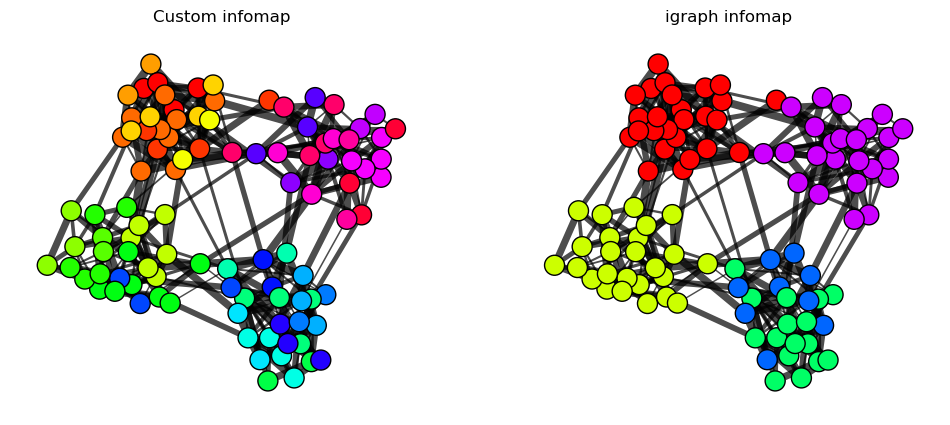

In [20]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[1])
ax[0].set_title("Custom infomap")
ax[1].set_title("igraph infomap")
plt.show()

Test full workflow for directed network:

In [21]:
communities = search_community_partition(g_test_directed, verbose=True)


--- Level 0 ------------------------------
    Current Graph: 100 nodes, 679 edges
Starting from description length: 8.505433022994854
Current best description length: 6.856190142777767
Number of nodes that have been moved this iteration: 76
Continuing optimization.
Current best description length: 6.462052521854485
Number of nodes that have been moved this iteration: 25
Continuing optimization.
Current best description length: 6.349676315782905
Number of nodes that have been moved this iteration: 9
Continuing optimization.
Current best description length: 6.332855496226703
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 6.332634002391673
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 6.31811530313404
Number of nodes that have been moved this iteration: 4
Continuing optimization.
Current best description length: 6.302668715150349
Number of nodes that have 

In [22]:
L_test = inf.compute_description_length(g_test_directed, communities)
print("Our best infomap description length: ", L_test)
# testing igraphs infomap implementation
comms_ig = g_test_directed.community_infomap(edge_weights="weight")
print("Igraph's best infomap description length: ", comms_ig.codelength)
print("Description legnth of igraph's best community assignment computed with our function: ", inf.compute_description_length(g_test_directed, comms_ig.membership))

Our best infomap description length:  6.302668715150351
Igraph's best infomap description length:  5.3590509519776885
Description legnth of igraph's best community assignment computed with our function:  5.7347817285886205


In [23]:
compare_partitions(communities, comms_ig.membership)

Normalized Mututal Information: 0.7015
Adjusted Rand Index: 0.5483


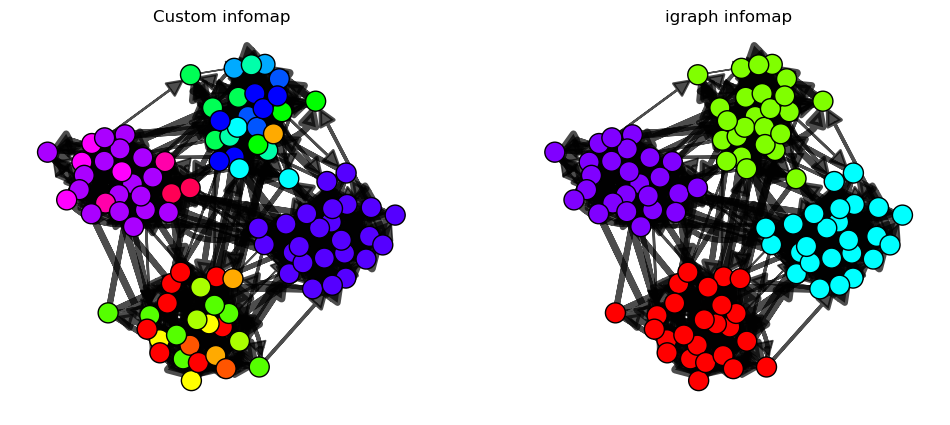

In [24]:
fig, ax = plt.subplots(ncols=2, figsize = (12, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=comms_ig.membership, skipLayout=True), target=ax[1])
ax[0].set_title("Custom infomap")
ax[1].set_title("igraph infomap")
plt.show()

Handover nodes:
- Implement search algorithm refinements
- benchmarking

*Submodule movements*. First, each cluster is treated as a network on its own and the main 
algorithm is applied to this network. This procedure generates one or more submodules 
for each module. Then all submodules are moved back to their respective modules of the 
previous step. At this stage, with the same partition as in the previous step but with 
each submodule being freely movable between the modules, the main algorithm is re-applied.

In [25]:
def submodule_movement_optimization(g: ig.Graph, communities: list[int], verbose=False) -> np.ndarray:
    """Refine a community partition via submodule movements:
    1. Take subgraphs corresponding to each module and run node-movement optimization to get 
        submodules
    2. Compress full network such that supernodes correspond to submodules
    3. Run node-movement optimization again, but startunf from the parent-module assignments

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        communities (list[int] | np.ndarray): Community label for each node. Labels need
            not be 0-indexed or contiguous (gaps from prior merge steps are handled).
        verbose (bool, optional): Print progress information. Defaults to False.

    Returns:
        np.ndarray: Refined community assignment for every node of g.
    """
    communities = np.array(communities, dtype=int)

    # Normalise community labels to contiguous 0-indexed integers.
    unique_comms = np.unique(communities)          # sorted unique labels
    n_mods       = len(unique_comms)
    comm_idx     = np.searchsorted(unique_comms, communities)   # 0-indexed community per node

    # node indices belonging to each module (list of 1-D arrays)
    comm_nodes = [np.where(comm_idx == i)[0] for i in range(n_mods)]

    if verbose:
        print(f"Submodule refinement: Starting with {n_mods} modules, {g.vcount()} nodes total.")
        for i, (comm, nodes) in enumerate(zip(unique_comms, comm_nodes)):
            print(f"  Module {comm} (idx {i}): {len(nodes)} nodes.")

    # Take each module and extract the corresponding subgraph, 
    # run the main node-movement optimisation and map the resulting local labels
    # to globally unique integers, simultaneously recording each submodule's
    # parent module index.
    global_submodule = np.empty(g.vcount(), dtype=int)  # global submodule label per node
    submodule_to_parent: list[int] = []  # parent module idx per submodule

    offset = 0 # offset to help with contiguous submodule labelling 
    for mod_idx, (nodes, subgraph) in enumerate(
        zip(comm_nodes, [g.induced_subgraph(nodes) for nodes in comm_nodes])): # get subgraphs corresponding to each community
        # perform node movement optimization step
        local_comms = np.array(inf.node_movement_optimization(subgraph, verbose=verbose), dtype=int)

        # Normalise local labels to contiguous 0-indexed integers,
        # then shift by offset to make them globally unique.
        local_unique  = np.unique(local_comms) # unique local submodule labels
        local_idx     = np.searchsorted(local_unique, local_comms)  # 0-indexed within module
        n_submodules  = len(local_unique) # number of submodules for the given subgraph

        global_submodule[nodes] = local_idx + offset # global submodule labels

        # Each local submodule belongs to the current parent module.
        submodule_to_parent.extend([mod_idx] * n_submodules) # update parent map
        offset += n_submodules # update offset

    submodule_to_parent = np.array(submodule_to_parent, dtype=int)
    n_total_submodules  = offset # total number of submodules

    if verbose:
        print(f"Created {n_total_submodules} submodules across {n_mods} modules.")

    # Network compression: each supernode corresponds to one submodule.
    # also returns unique submodule labels to allow reconstruction of node assignments
    g_compressed, unique_submodule_labels = inf.compress_network(g, global_submodule, verbose=verbose)


    # unique_submodule_labels[i] is the global submodule label of compressed node i,
    # so indexing submodule_to_parent with it gives the parent module index for each compressed node.
    initial_compressed_comms = submodule_to_parent[unique_submodule_labels]

    if verbose:
        print(f"  Compressed nodes: {g_compressed.vcount()}, "
              f"unique initial communities: {len(np.unique(initial_compressed_comms))}")

    # Performing node-movement optimization on compressed network, with an initial
    # community partition corresponding to the result of the core search algorithm
    # so each compressed node (submodule) is initially assigned to its parent module.
    final_compressed_comms = np.array(
        inf.node_movement_optimization(g_compressed,
                                       initial_communities=initial_compressed_comms,
                                       verbose=verbose,
                                       ),
        dtype=int,
    )

    # map the refined partition back to og nodes
    compressed_node_idx = np.searchsorted(unique_submodule_labels, global_submodule)
    final_communities   = final_compressed_comms[compressed_node_idx]

    if verbose:
        n_final = len(np.unique(final_communities))
        print(f"Submodule refinement complete: {n_mods} -> {n_final} communities.")

    return final_communities

In [26]:
final_communities = submodule_movement_optimization(g_test, communities, verbose=True)
print(final_communities)

Submodule refinement: Starting with 18 modules, 100 nodes total.
  Module 0 (idx 0): 8 nodes.
  Module 1 (idx 1): 2 nodes.
  Module 2 (idx 2): 3 nodes.
  Module 3 (idx 3): 3 nodes.
  Module 4 (idx 4): 3 nodes.
  Module 5 (idx 5): 7 nodes.
  Module 6 (idx 6): 3 nodes.
  Module 7 (idx 7): 4 nodes.
  Module 8 (idx 8): 3 nodes.
  Module 9 (idx 9): 3 nodes.
  Module 10 (idx 10): 2 nodes.
  Module 11 (idx 11): 3 nodes.
  Module 12 (idx 12): 6 nodes.
  Module 13 (idx 13): 25 nodes.
  Module 14 (idx 14): 17 nodes.
  Module 15 (idx 15): 4 nodes.
  Module 16 (idx 16): 2 nodes.
  Module 17 (idx 17): 2 nodes.
Starting from description length: 4.9186960264014505
Current best description length: 3.0222680652668013
Number of nodes that have been moved this iteration: 5
Continuing optimization.
Current best description length: 2.584839003547305
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 2.503576917863987
Number of nodes that have be

In [27]:
def search_community_partition(g:ig.Graph, doSubmoduleMovements=False, verbose=False):

    N = g.vcount() # number of nodes in graph
    flat_comms = np.arange(N, dtype=int) # we'll use this to track how each node in the og graph
    # maps to the supernodes of the current compressed graph

    g_current = g 
    level = 0 # tracking the compression depth

    # start with a loop that repeats as long as we still have improvements:
    improved = True
    while improved:
        n_current = g_current.vcount()
        if verbose:
            print(f"\n--- Level {level} ------------------------------")
            print(f"    Current Graph: {n_current} nodes, {g_current.ecount()} edges")
    
        # --- Phase 1: optimization via single-node moves ---
        comms_level = inf.node_movement_optimization(g_current, verbose=verbose)
        comms_unique = np.unique(comms_level) # get sorted list of unique communities
        n_communities = len(comms_unique) # number of unique communities

        if verbose:
            print(f"    Phase 1 found {n_communities} communities")

        # if no improvement has been made in node movement optimization, exit loop
        if n_communities == n_current:  # if we still have 1 community per node after node optimization
            if verbose:
                print(f"    Moving (super)nodes didn't improve codelength, stopping optimization.")
            break

        # --- Update node mapping ---
        # get for each node in the current level graph the corresponding community
        # indices after optimization (corresponding to supernode indices of the compressed graph
        # that will be created in the next step
        node_to_super = np.searchsorted(comms_unique, comms_level)  # shape (n_current,)
        # get mapping back to og nodes
        flat_comms    = node_to_super[flat_comms]         
        
        # --- Phase 2: Network compression ---
        g_current, _ = inf.compress_network(g_current, comms_level, verbose=verbose)
        if verbose: 
            print(f"    Compressed network has description length L = {inf.compute_description_length(g_current, range(n_communities))}")
        level += 1
        
    # Normalise: make community labels contiguous and 0-indexed. 
    # (bc rn the labels could have gaps) 
    # works neatly with the inverse labels from np.unique
    _, flat_comms = np.unique(flat_comms, return_inverse=True)

    if doSubmoduleMovements:
        refined_comms = submodule_movement_optimization(g, flat_comms, verbose=verbose)

    if verbose:
        L_final = inf.compute_description_length(g, flat_comms.tolist())
        print(f"\nFinal: {len(np.unique(flat_comms))} communities, "
              f"L = {L_final:.6f} bits")

    return flat_comms.tolist()
        